### Search Engine Berita Sederhana dengan Pendeteksian Berita Hoax
#### Nama : Raihan Agil Wijaya
#### NIM  : A11.2022.14017
#### Kelompok : A11.4701

### Ringkasan Projek
Projek ini bertujuan untuk mengembangkan mesin pencari sederhana yang mampu
mengidentifikasi dan mengklasifikasikan berita hoaks dari berbagai sumber berita. Mesin
pencari ini akan menggunakan Sistem Temu Kembali Informasi untuk menganalisis dan
mengekstrak fitur dari berita yang ada dalam dataset yang nantinya kemudian akan dilakukan
teknik pra pemrosesan untuk dijadikan sebagai clean dataset seperti melakukan case folding
(menjadikan kalimat menjadi huruf kecil, menghilangkan angka, menghilangkan karakter
kosong), steemming dimana kita menjadikan kata yang memiliki imbuhan menjadi kata dasar, kemudian nantinya pengguna dapat memasukkan query untuk mencari dokumen berita yang
sesuai dengan inputan mereka

### Masalah
Masalah yang harus diselesaikan dalam pembuatan search engine / mesin pencarian ini
adalah bagaimana cara membuat search engine yang dapat mendapatkan dokumen secara
akurat dari inputan query user, dan juga query yang diinputkan user juga dapat disesuaikan
sehingga jika terdapat kesalahan input seperti typo, sistem pencarian paling tidak masih dapat
mencari informasi yang dimaksud tanpa mengalami hambatan dari typo user

### Tujuan
Tujuan dari penyelesaian masalah diatas adalah untuk membuat suatu sistem mesin pencarian
/ search engine yang efektif, serta juga dapat mengambil informasi secara akurat sehingga
mesin pencarian ini dapat mengidentifikasi dan mencari dokumen berita hoaks pada dataset
sehingga dapat digunakan untuk mengembangkan fitur pencarian yang efektif bedasarkan
kata kunci yang diinputkan

## Bagan
![alt text](Bagan.png)

## Penjelasan Dataset

A. Dataset CNN:
Title: Judul dari dokumen berita
Timestamp: Waktu publikasi dokumen berita
FullText: Isi pembuka dan juga penutup dari dokumen berita
Tags: Kata kunci dari dokumen berita
Author: Pengarang dari dokumen berita
Url: Situs dokumen berita
Text New: Isi utama dari dokumen berita
Hoax: Status Hoax/tidak dokumen berita
B. Dataset Turnback Hoax
Title: Judul dari dokumen berita
Timestamp: Waktu publikasi dokumen berita
FullText: Isi keseluruhan dari dokumen berita
Tags: Kata kunci dari dokumen berita
Author: Pengarang dari dokumen berita
Url: Situs dokumen berita
Politik: Angka yang merepresentasikan hubungan antara berita dengan politik
Narasi: Potongan narasi dari dokumen berita
Clean_Narasi: Potongan narasi yang sudah dibersihkan dan diproses
Hoax: Status Hoax/tidak dokumen berita

## Proses Feature Dataset dan EDA Dataset

Proses fitur dataset dan juga EDA Dataset saya lakukan dengan cara menunjukkan hasil hasil dari pemrosesan dataset yang saya lakukan serta juga menunjukkan label dan juga feature dataset sebelum dataset akan ditrain

# Preprocessing Data

1. Case Folding

In [1]:
import pandas as pd
import string

df = pd.read_excel('Dataset.xlsx')

def text_preprocessing(text):
    # Check if the text is NaN or not a string, return an empty string if so
    if not isinstance(text, str):
        return ''
    
    # Remove punctuation and numbers
    text = text.translate(str.maketrans('', '', string.punctuation + '0123456789'))
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra spaces
    text = ' '.join(text.split()) 
    
    return text

# Apply text preprocessing to the 'Text' column
df['Processed_Text'] = df['Text'].apply(text_preprocessing)

# Save Data to CSV
df.to_csv('Case_Folding_Dataset.csv', index=False)

# Display the first few rows
print(df[['Text', 'Processed_Text']].head())

                                                Text  \
0  Anies di Milad BKMT: Pengajian Menghasilkan Ib...   
1  Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...   
2  PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...   
3  Gede Pasek Doakan AHY Jadi Capres atau Cawapre...   
4  PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...   

                                      Processed_Text  
0  anies di milad bkmt pengajian menghasilkan ibu...  
1  edy soal pilgub sumut kalau yang maju abalabal...  
2  pkb bakal daftarkan menaker ida fauziyah jadi ...  
3  gede pasek doakan ahy jadi capres atau cawapre...  
4  pkn siapkan jabatan khusus buat anas urbaningr...  


# Normalisasi Kata

In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\windo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\windo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
def word_tokenize_wrapper(text):
  return word_tokenize(text)

In [4]:
df["Tokenized_Text"] = df['Processed_Text'].apply(word_tokenize_wrapper)
df.to_csv('Tokenized_Dataset.csv', index=False)
print(df[['Processed_Text', 'Tokenized_Text']].head())

                                      Processed_Text  \
0  anies di milad bkmt pengajian menghasilkan ibu...   
1  edy soal pilgub sumut kalau yang maju abalabal...   
2  pkb bakal daftarkan menaker ida fauziyah jadi ...   
3  gede pasek doakan ahy jadi capres atau cawapre...   
4  pkn siapkan jabatan khusus buat anas urbaningr...   

                                      Tokenized_Text  
0  [anies, di, milad, bkmt, pengajian, menghasilk...  
1  [edy, soal, pilgub, sumut, kalau, yang, maju, ...  
2  [pkb, bakal, daftarkan, menaker, ida, fauziyah...  
3  [gede, pasek, doakan, ahy, jadi, capres, atau,...  
4  [pkn, siapkan, jabatan, khusus, buat, anas, ur...  


In [5]:
normalized_word = pd.read_excel("kamus perbaikan kata.xlsx")

normalized_word_dict = {}

for index, row in normalized_word.iterrows():
    if row[0] not in normalized_word_dict:
        normalized_word_dict[row[0]] = row[1]

def normalized_term(document):
    return [normalized_word_dict[term] if term in normalized_word_dict else term for term in document]

df['Fixed_Token'] = df['Tokenized_Text'].apply(normalized_term)
print(df[['Tokenized_Text', 'Fixed_Token']].head())

                                      Tokenized_Text  \
0  [anies, di, milad, bkmt, pengajian, menghasilk...   
1  [edy, soal, pilgub, sumut, kalau, yang, maju, ...   
2  [pkb, bakal, daftarkan, menaker, ida, fauziyah...   
3  [gede, pasek, doakan, ahy, jadi, capres, atau,...   
4  [pkn, siapkan, jabatan, khusus, buat, anas, ur...   

                                         Fixed_Token  
0  [anies, di, milad, bkmt, pengajian, menghasilk...  
1  [edy, soal, pilgub, sumut, kalau, yang, maju, ...  
2  [pkb, bakal, daftarkan, menaker, ida, fauziyah...  
3  [besar, pasek, doakan, ahy, jadi, capres, atau...  
4  [pkn, siapkan, jabatan, khusus, buat, anas, ur...  


C:\Users\windo\AppData\Local\Temp\ipykernel_5840\3432827364.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[0] not in normalized_word_dict:
C:\Users\windo\AppData\Local\Temp\ipykernel_5840\3432827364.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normalized_word_dict[row[0]] = row[1]


# Menghilangkan Stopword

In [6]:
from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\windo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
stopword = nltk.corpus.stopwords.words('indonesian')

def remove_stopwords(text):
  text = [word for word in text if word not in stopword]
  return text

df['Stop_removal'] = df['Fixed_Token'].apply(lambda x: remove_stopwords(x))
df

,Unnamed: 0,Title,Text,Hoax,Processed_Text,Tokenized_Text,Fixed_Token,Stop_removal
0,1,Anies di Milad BKMT: Pengajian Menghasilkan Ib...,Anies di Milad BKMT: Pengajian Menghasilkan Ib...,0,anies di milad bkmt pengajian menghasilkan ibu...,"[anies, di, milad, bkmt, pengajian, menghasilk...","[anies, di, milad, bkmt, pengajian, menghasilk...","[anies, milad, bkmt, pengajian, menghasilkan, ..."
1,2,Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...,Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...,0,edy soal pilgub sumut kalau yang maju abalabal...,"[edy, soal, pilgub, sumut, kalau, yang, maju, ...","[edy, soal, pilgub, sumut, kalau, yang, maju, ...","[edy, pilgub, sumut, maju, abalabal, terpaksa,..."
2,3,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,0,pkb bakal daftarkan menaker ida fauziyah jadi ...,"[pkb, bakal, daftarkan, menaker, ida, fauziyah...","[pkb, bakal, daftarkan, menaker, ida, fauziyah...","[pkb, daftarkan, menaker, ida, fauziyah, caleg..."
3,4,Gede Pasek Doakan AHY Jadi Capres atau Cawapres,Gede Pasek Doakan AHY Jadi Capres atau Cawapre...,0,gede pasek doakan ahy jadi capres atau cawapre...,"[gede, pasek, doakan, ahy, jadi, capres, atau,...","[besar, pasek, doakan, ahy, jadi, capres, atau...","[pasek, doakan, ahy, capres, cawapres, ketua, ..."
4,5,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,0,pkn siapkan jabatan khusus buat anas urbaningr...,"[pkn, siapkan, jabatan, khusus, buat, anas, ur...","[pkn, siapkan, jabatan, khusus, buat, anas, ur...","[pkn, siapkan, jabatan, khusus, anas, urbaning..."
...,...,...,...,...,...,...,...,...
995,996,Meletakkan Bawang Putih Di Telinga Bisa Menyem...,Akun Facebook Lita Al Alip memposting sebuah i...,1,akun facebook lita al alip memposting sebuah i...,"[akun, facebook, lita, al, alip, memposting, s...","[akun, facebook, lita, al, alip, memposting, s...","[akun, facebook, lita, al, alip, memposting, i..."
996,997,Upacara HUT RI ke-77 yang Dipimpin oleh Anies ...,Akun Facebook Rissa Adistie memposting sebuah ...,1,akun facebook rissa adistie memposting sebuah ...,"[akun, facebook, rissa, adistie, memposting, s...","[akun, facebook, rissa, adistie, memposting, s...","[akun, facebook, rissa, adistie, memposting, v..."
997,998,Pidato Anies Baswedan: “Saya Merancang Grand D...,Akun Twitter @mahasiswigenz mengunggah potonga...,1,akun twitter mahasiswigenz mengunggah potongan...,"[akun, twitter, mahasiswigenz, mengunggah, pot...","[akun, twitter, mahasiswigenz, mengunggah, pot...","[akun, twitter, mahasiswigenz, mengunggah, pot..."
998,999,Ferdy Sambo Mengamuk dan Ancam akan Buka Borok...,Berita tentang kasus yang melibatkan pejabat t...,1,berita tentang kasus yang melibatkan pejabat t...,"[berita, tentang, kasus, yang, melibatkan, pej...","[berita, tentang, kasus, yang, melibatkan, pej...","[berita, melibatkan, pejabat, kepolisian, ferd..."


In [8]:
i=0
final_string_tokens = []
for text in df['Stop_removal'].values:
    EachReviewText = ""
    EachReviewText = ' '.join(text)
    final_string_tokens.append(EachReviewText)

In [9]:
df["step2"] = final_string_tokens
df.to_csv('StopRemoval_Dataset.csv', index=False)
df.head()

,Unnamed: 0,Title,Text,Hoax,Processed_Text,Tokenized_Text,Fixed_Token,Stop_removal,step2
0,1,Anies di Milad BKMT: Pengajian Menghasilkan Ib...,Anies di Milad BKMT: Pengajian Menghasilkan Ib...,0,anies di milad bkmt pengajian menghasilkan ibu...,"[anies, di, milad, bkmt, pengajian, menghasilk...","[anies, di, milad, bkmt, pengajian, menghasilk...","[anies, milad, bkmt, pengajian, menghasilkan, ...",anies milad bkmt pengajian menghasilkan ibuibu...
1,2,Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...,Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...,0,edy soal pilgub sumut kalau yang maju abalabal...,"[edy, soal, pilgub, sumut, kalau, yang, maju, ...","[edy, soal, pilgub, sumut, kalau, yang, maju, ...","[edy, pilgub, sumut, maju, abalabal, terpaksa,...",edy pilgub sumut maju abalabal terpaksa maju g...
2,3,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,0,pkb bakal daftarkan menaker ida fauziyah jadi ...,"[pkb, bakal, daftarkan, menaker, ida, fauziyah...","[pkb, bakal, daftarkan, menaker, ida, fauziyah...","[pkb, daftarkan, menaker, ida, fauziyah, caleg...",pkb daftarkan menaker ida fauziyah caleg dpr p...
3,4,Gede Pasek Doakan AHY Jadi Capres atau Cawapres,Gede Pasek Doakan AHY Jadi Capres atau Cawapre...,0,gede pasek doakan ahy jadi capres atau cawapre...,"[gede, pasek, doakan, ahy, jadi, capres, atau,...","[besar, pasek, doakan, ahy, jadi, capres, atau...","[pasek, doakan, ahy, capres, cawapres, ketua, ...",pasek doakan ahy capres cawapres ketua partai ...
4,5,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,0,pkn siapkan jabatan khusus buat anas urbaningr...,"[pkn, siapkan, jabatan, khusus, buat, anas, ur...","[pkn, siapkan, jabatan, khusus, buat, anas, ur...","[pkn, siapkan, jabatan, khusus, anas, urbaning...",pkn siapkan jabatan khusus anas urbaningrum be...


# Stemming

In [10]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [11]:
final_string = []
s = ""
for sentence in df["step2"].values:
    filteredSentence = []
    EachReviewText = ""
    s = (stemmer.stem(sentence))
    filteredSentence.append(s)

    EachReviewText = ' '.join(filteredSentence)
    final_string.append(EachReviewText)

In [12]:
df["ProcessedText"] = final_string

In [13]:
df.head(10)

,Unnamed: 0,Title,Text,Hoax,Processed_Text,Tokenized_Text,Fixed_Token,Stop_removal,step2,ProcessedText
0,1,Anies di Milad BKMT: Pengajian Menghasilkan Ib...,Anies di Milad BKMT: Pengajian Menghasilkan Ib...,0,anies di milad bkmt pengajian menghasilkan ibu...,"[anies, di, milad, bkmt, pengajian, menghasilk...","[anies, di, milad, bkmt, pengajian, menghasilk...","[anies, milad, bkmt, pengajian, menghasilkan, ...",anies milad bkmt pengajian menghasilkan ibuibu...,anies milad bkmt aji hasil ibuibu tahu mantan ...
1,2,Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...,Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...,0,edy soal pilgub sumut kalau yang maju abalabal...,"[edy, soal, pilgub, sumut, kalau, yang, maju, ...","[edy, soal, pilgub, sumut, kalau, yang, maju, ...","[edy, pilgub, sumut, maju, abalabal, terpaksa,...",edy pilgub sumut maju abalabal terpaksa maju g...,edy pilgub sumut maju abalabal paksa maju gube...
2,3,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,0,pkb bakal daftarkan menaker ida fauziyah jadi ...,"[pkb, bakal, daftarkan, menaker, ida, fauziyah...","[pkb, bakal, daftarkan, menaker, ida, fauziyah...","[pkb, daftarkan, menaker, ida, fauziyah, caleg...",pkb daftarkan menaker ida fauziyah caleg dpr p...,pkb daftar menaker ida fauziyah caleg dpr milu...
3,4,Gede Pasek Doakan AHY Jadi Capres atau Cawapres,Gede Pasek Doakan AHY Jadi Capres atau Cawapre...,0,gede pasek doakan ahy jadi capres atau cawapre...,"[gede, pasek, doakan, ahy, jadi, capres, atau,...","[besar, pasek, doakan, ahy, jadi, capres, atau...","[pasek, doakan, ahy, capres, cawapres, ketua, ...",pasek doakan ahy capres cawapres ketua partai ...,pasek doa ahy capres cawapres ketua partai ban...
4,5,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,0,pkn siapkan jabatan khusus buat anas urbaningr...,"[pkn, siapkan, jabatan, khusus, buat, anas, ur...","[pkn, siapkan, jabatan, khusus, buat, anas, ur...","[pkn, siapkan, jabatan, khusus, anas, urbaning...",pkn siapkan jabatan khusus anas urbaningrum be...,pkn siap jabat khusus anas urbaningrum bebas a...
5,6,"Nurdin: Kalaupun Bukan Menpora, Jatah Golkar d...","Nurdin: Kalaupun Bukan Menpora, Jatah Golkar d...",0,nurdin kalaupun bukan menpora jatah golkar di ...,"[nurdin, kalaupun, bukan, menpora, jatah, golk...","[nurdin, kalaupun, bukan, menpora, jatah, golk...","[nurdin, menpora, jatah, golkar, kabinet, berk...",nurdin menpora jatah golkar kabinet berkurang ...,nurdin menpora jatah golkar kabinet kurang wak...
6,7,HNW Sebut PKS Deklarasi Anies Capres Secara Re...,HNW Sebut PKS Deklarasi Anies Capres Secara Re...,0,hnw sebut pks deklarasi anies capres secara re...,"[hnw, sebut, pks, deklarasi, anies, capres, se...","[hnw, sebut, pks, deklarasi, anies, capres, se...","[hnw, pks, deklarasi, anies, capres, resmi, ra...",hnw pks deklarasi anies capres resmi rakernas ...,hnw pks deklarasi anies capres resmi rakernas ...
7,8,Jazilul PKB Sindir PPP: Jangan Kayak Partai Ij...,Jazilul PKB Sindir PPP: Jangan Kayak Partai Ij...,0,jazilul pkb sindir ppp jangan kayak partai ijo...,"[jazilul, pkb, sindir, ppp, jangan, kayak, par...","[jazilul, pkb, sindir, ppp, jangan, kayak, par...","[jazilul, pkb, sindir, ppp, kayak, partai, ijo...",jazilul pkb sindir ppp kayak partai ijo kursi ...,jazilul pkb sindir ppp kayak partai ijo kursi ...
8,9,Eks Politikus PDIP Laksamana Sukardi Gabung PK...,Eks Politikus PDIP Laksamana Sukardi Gabung PK...,0,eks politikus pdip laksamana sukardi gabung pk...,"[eks, politikus, pdip, laksamana, sukardi, gab...","[eks, politikus, pdip, laksamana, sukardi, gab...","[eks, politikus, pdip, laksamana, sukardi, gab...",eks politikus pdip laksamana sukardi gabung pk...,eks politikus pdip laksamana sukardi gabung pk...
9,10,"PKS Gelar Rakernas Akhir Pekan Ini, Anies Dija...","PKS Gelar Rakernas Akhir Pekan Ini, Anies Dija...",0,pks gelar rakernas akhir pekan ini anies dijad...,"[pks, gelar, rakernas, ak

In [14]:
df.to_csv('clean_dataset_part01.csv',sep=";")

In [15]:
dataset = pd.read_csv('clean_dataset_part01.csv',sep=";")
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    1000 non-null   int64 
 1   Unnamed: 0      1000 non-null   int64 
 2   Title           1000 non-null   object
 3   Text            998 non-null    object
 4   Hoax            1000 non-null   int64 
 5   Processed_Text  998 non-null    object
 6   Tokenized_Text  1000 non-null   object
 7   Fixed_Token     1000 non-null   object
 8   Stop_removal    1000 non-null   object
 9   step2           998 non-null    object
 10  ProcessedText   998 non-null    object
dtypes: int64(3), object(8)
memory usage: 86.1+ KB


In [16]:
dataset_feature = dataset['ProcessedText'].astype(str)

dataset_feature.head(10)

0    anies milad bkmt aji hasil ibuibu tahu mantan ...
1    edy pilgub sumut maju abalabal paksa maju gube...
2    pkb daftar menaker ida fauziyah caleg dpr milu...
3    pasek doa ahy capres cawapres ketua partai ban...
4    pkn siap jabat khusus anas urbaningrum bebas a...
5    nurdin menpora jatah golkar kabinet kurang wak...
6    hnw pks deklarasi anies capres resmi rakernas ...
7    jazilul pkb sindir ppp kayak partai ijo kursi ...
8    eks politikus pdip laksamana sukardi gabung pk...
9    pks gelar rakernas pekan anies jadwal hadir pa...
Name: ProcessedText, dtype: object

In [17]:
dataset_label = dataset['Hoax']
dataset_label.head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Hoax, dtype: int64

# Distribusi Label

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

C:\Users\windo\AppData\Local\Temp\ipykernel_5840\48192011.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset_label, label=f'target, skew: {dataset_label.skew():.2f}')


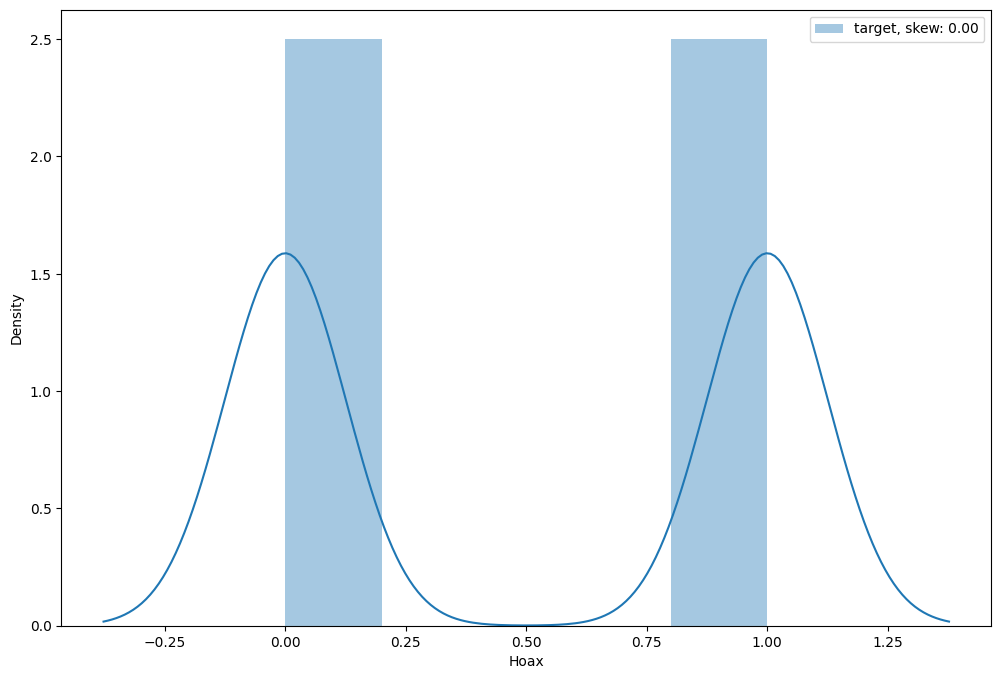

In [19]:
plt.figure(figsize=(12,8))
sns.distplot(dataset_label, label=f'target, skew: {dataset_label.skew():.2f}')
plt.legend(loc='best')
plt.show()

# Ekstraksi Fitur & Machine Learning

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split

In [21]:
train_x, test_x, train_label, test_label = train_test_split(dataset_feature, dataset_label, test_size = 0.3, random_state=42)
test_x

521    video asli ambil kereta bawa bahan kimia ohio ...
737    viral mahfud md bngkr ksus sup balik sidang fe...
740    innalillahi pesan venna melinda alm tinggal dunia
660    messi ktanya persib et sumber twitterhttpsarch...
411    isu reshuffle surya paloh suasana batin jokowi...
                             ...                        
468    nasdem respons isu spanduk tolak anies ntb ket...
935    gambar sejarah ka bah masjidil haram limut war...
428    jokowi bangga menang bareng ahok pilkada dki p...
7      jazilul pkb sindir ppp kayak partai ijo kursi ...
155    survei populi elektabilitas anies anjlok jabat...
Name: ProcessedText, Length: 300, dtype: object

# Load TF IDF

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf_Vectorizer = TfidfVectorizer()

# Naive Bayes

In [23]:
from sklearn.naive_bayes import MultinomialNB

In [24]:
from sklearn.pipeline import Pipeline
classifier_nb = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', MultinomialNB()),
])

In [25]:
parameters_nb = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3), (1, 4)],
    'model__alpha': (0.0001, 0.001, 0.1, 1, 10, 100)
}

In [26]:
classifier_nb = GridSearchCV(classifier_nb, parameters_nb, cv = 3, n_jobs=-1)

In [27]:
classifier_nb.fit(train_x, train_label.ravel())

C:\Users\windo\AppData\Local\Temp\ipykernel_5840\4039834798.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  classifier_nb.fit(train_x, train_label.ravel())


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('model', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'model__alpha': (0.0001, 0.001, 0.1, 1, 10, 100),
                         'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3),
                                                (1, 4)]})

In [28]:
y_pred_nb_train = classifier_nb.predict(train_x)
accuracy_nb_train = accuracy_score(train_label, y_pred_nb_train)
print("Accuracy Training set: ", accuracy_nb_train)

y_pred_nb_test = classifier_nb.predict(test_x)
accuracy_nb_test = accuracy_score(test_label, y_pred_nb_test)
print("Accuracy Test set: ", accuracy_nb_test)

Accuracy Training set:  0.9971428571428571
Accuracy Test set:  0.95


In [29]:
recall_nb_train = recall_score(train_label, y_pred_nb_train, average='weighted')
print("Recall Training set: ", recall_nb_train)

recall_nb_test = recall_score(test_label, y_pred_nb_test, average='weighted')
print("Recall Test set: ", recall_nb_test)

Recall Training set:  0.9971428571428571
Recall Test set:  0.95


In [30]:
precision_nb_train = precision_score(train_label, y_pred_nb_train, average='weighted')
print("Precision Training set: ", precision_nb_train)

precision_nb_test = precision_score(test_label, y_pred_nb_test, average='weighted')
print("Precision Test set: ", precision_nb_test)

Precision Training set:  0.9971590909090909
Precision Test set:  0.9545454545454546


In [31]:
f1_nb_train = f1_score(train_label, y_pred_nb_train, average='weighted')
print("F1 Training set: ", f1_nb_train)

f1_nb_test = f1_score(test_label, y_pred_nb_test, average='weighted')
print("F1 Test set: ", f1_nb_test)

F1 Training set:  0.9971428338190517
F1 Test set:  0.9498746867167919


# Confusion Matrix

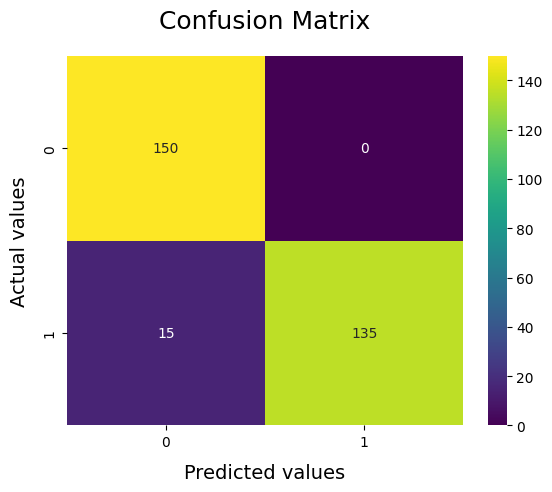

In [32]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(test_label, y_pred_nb_test), annot=True, cmap = 'viridis', fmt='.0f')
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values"   , fontdict = {'size':14}, labelpad = 10)
plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)
plt.show()

# Visualisasi

In [33]:
models = [
          ('Naive Bayes Multinomial', accuracy_nb_train, accuracy_nb_test),
         ]

In [34]:
predict = pd.DataFrame(data = models, columns=['Model', 'Training Accuracy', 'Test Accuracy'])
predict

,Model,Training Accuracy,Test Accuracy
0,Naive Bayes Multinomial,0.997143,0.95


In [35]:
models_comparison = [
                        ('Naive Bayes Multinomial', accuracy_nb_test, recall_nb_test, precision_nb_test, f1_nb_test)
                    ]

In [36]:
comparison = pd.DataFrame(data = models_comparison, columns=['Model', 'Accuracy', 'Recall', 'Precision', 'F1 Weighted'])
comparison

,Model,Accuracy,Recall,Precision,F1 Weighted
0,Naive Bayes Multinomial,0.95,0.95,0.954545,0.949875


C:\Users\windo\AppData\Local\Temp\ipykernel_5840\2750282873.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Training Accuracy', y='Model', data = predict, palette='Blues_d', ax = axes[0])
C:\Users\windo\AppData\Local\Temp\ipykernel_5840\2750282873.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Test Accuracy', y='Model', data = predict, palette='Greens_d', ax = axes[1])


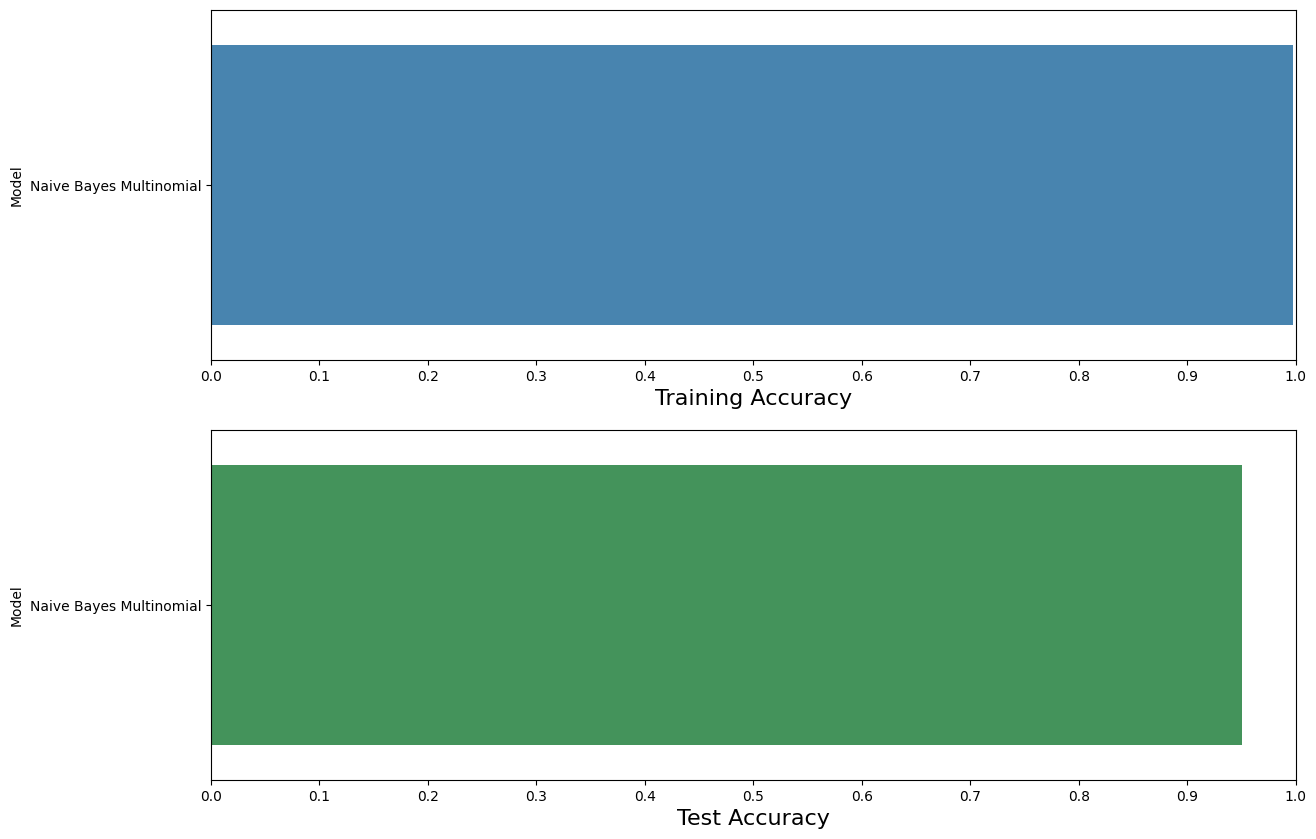

In [37]:
import numpy as np

f, axes = plt.subplots(2,1, figsize=(14,10))

predict.sort_values(by=['Training Accuracy'], ascending=False, inplace=True)

sns.barplot(x='Training Accuracy', y='Model', data = predict, palette='Blues_d', ax = axes[0])
#axes[0].set(xlabel='Region', ylabel='Charges')
axes[0].set_xlabel('Training Accuracy', size=16)
axes[0].set_ylabel('Model')
axes[0].set_xlim(0,1.0)
axes[0].set_xticks(np.arange(0, 1.1, 0.1))

predict.sort_values(by=['Test Accuracy'], ascending=False, inplace=True)

sns.barplot(x='Test Accuracy', y='Model', data = predict, palette='Greens_d', ax = axes[1])
#axes[0].set(xlabel='Region', ylabel='Charges')
axes[1].set_xlabel('Test Accuracy', size=16)
axes[1].set_ylabel('Model')
axes[1].set_xlim(0,1.0)
axes[1].set_xticks(np.arange(0, 1.1, 0.1))

plt.show()

## Diskusi

Untuk sistem pengklasifikasian deteksi berita apakah hoax / tidak bedasarkan dari training dan test accuracy, sudah tampak bagus, sehingga model klasifikasi diatas dapat digunakan pada search engine agar kita dapat mengetikkan query dan nantinya kita dapat melihat apakah query dari search engine yang kita buat dapat menentukan apakah query tersebut termasuk ke dalam berita Hoax. Namun untuk sekarang ini karena pembuatan aplikasi masih terhalang karena eksperimen projek yang saya buat ini masih saya lakukan pada saat saya masih dirawat di rumah sakit maka untuk hasil yang maksimal masih dalam tahap pembuatan classifier menggunakan naive bayes, sedangkan untuk lanjutan dari search engine belum memungkinkan untuk dibuat karena masih terkendala kesehatan, untuk itu saya ingin meminta maaf sebesar besarnya karena projek ini harus terhalang untuk kemajuannya yang membuat projek ini kurang maksimal, untuk percobaan kode simple search engine sudah terdapat beberapa versi code yang ada dibawah bagian diskusi ini untuk pembuatan search engine

# Simple Query Engine

In [38]:
import glob
import re
import os
from nltk.tokenize import sent_tokenize , word_tokenize

def finding_all_unique_words_and_freq(words):
    words_unique = []
    word_freq = {}
    for word in words:
        if word not in words_unique:
            words_unique.append(word)
    for word in words_unique:
        word_freq[word] = words.count(word)
    return word_freq
def finding_freq_of_word_in_doc(word,words):
    freq = words.count(word)
        
def remove_special_characters(text):
    regex = re.compile('[^a-zA-Z0-9\s]')
    text_returned = re.sub(regex,'',text)
    return text_returned

In [39]:
class Node:
    def __init__(self, docId, freq=None):
        self.freq = freq
        self.doc = docId
        self.nextval = None
    
class SlinkedList:
    def __init__(self, head=None):
        self.head = head

In [40]:
import pandas as pd
import re
from nltk.tokenize import sent_tokenize, word_tokenize

all_words = [] 
dict_global = {}
csv_file_path = 'clean_dataset_part01.csv'  # Path to your CSV file
idx = 1
files_with_index = {}
Stopwords = set()  # Define your stopwords set here

# Read the CSV file
df = pd.read_csv(csv_file_path)

# Assuming the column with text data is named 'text_column'
for _, row in df.iterrows():
    text = row['ProcessedText']  # Replace 'text_column' with the actual column name in your CSV
    text = str(text)  # Ensure text is a string
    text = remove_special_characters(text)  # Function to clean special characters
    text = re.sub(r'\d', '', text)  # Regex to remove digits

    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    words = [word for word in words if len(word) > 1]  # Check length of each word
    words = [word.lower() for word in words]
    words = [word for word in words if word not in Stopwords]  # Ensure Stopwords is defined

    dict_global.update(finding_all_unique_words_and_freq(words))
    files_with_index[idx] = row['id'] if 'id' in row else f"Row_{idx}"  # Optionally map index to a row identifier
    idx += 1  # Simplified increment

# Create a set of unique words
unique_words_all = set(dict_global.keys())  # Convert dict keys to a set

print("Unique Words:", unique_words_all)


ParserError: Error tokenizing data. C error: Expected 695 fields in line 9, saw 973


In [43]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Load the CSV file
file_path = "clean_dataset_part01.csv"  # Replace with your CSV file path
df = pd.read_csv(file_path)

# Step 2: Extract the text data column (replace 'news_text' with your column name)
if 'ProcessedText' in df.columns:  # Ensure the column exists
    text_data = df['ProcessedText'].dropna().tolist()  # Handle missing values by dropping them
else:
    raise ValueError("The column does not exist in the dataset.")

# Step 3: Initialize and fit the TfidfVectorizer
Tfidf_Vectorizer = TfidfVectorizer(stop_words='indonesian')
Tfidf_Vectorizer.fit(text_data)

# Optional: Transform the dataset into a TF-IDF matrix
tfidf_matrix = Tfidf_Vectorizer.transform(text_data)

# Example: Print the vocabulary
print("Vocabulary:", Tfidf_Vectorizer.vocabulary_)

# Example: Transform a new query
query = [" NasDem dan Demokrat tengah menjajaki koalisi menghadapi Pilpres 2024 mendatang."]
query_vectorized = Tfidf_Vectorizer.transform(query)
print("Query vectorized:", query_vectorized.toarray())

ParserError: Error tokenizing data. C error: Expected 695 fields in line 9, saw 973
